<a href="https://colab.research.google.com/github/IA-MachineLearning-Relatorios/Regression-Trees-Pruning/blob/main/Regression%26Prunning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

Encontradas 8 colunas obejct que rpecisam ser trnaformadas em numeros

porem foi encontrado varias colunas com valores nao nulos que teremso q aplicar a regra de imputacao de dados, aplicar mediana nesses dados faltantes para nao termos grande parte do dataset apagado

In [2]:
mediana = df['Engine HP'].median()
df['Engine HP'] = df['Engine HP'].fillna(mediana)

#teste
df['Engine HP'].isnull().sum()

np.int64(0)

muitas colunas tem valores faltnates, algumas numericas e outras categoricas, agora realzei o parciamento do dataset para resolver isto

In [3]:
X = df.drop('MSRP', axis=1)
y = df['MSRP']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [4]:
mediana_hp = X_train['Engine HP'].median()  # calculado SÓ no treino

X_train['Engine HP'] = X_train['Engine HP'].fillna(mediana_hp)
X_test['Engine HP'] = X_test['Engine HP'].fillna(mediana_hp)  # aplica o MESMO valor

mediana_Cylinders = X_train['Engine Cylinders'].median()

X_train['Engine Cylinders'] = X_train['Engine Cylinders'].fillna(mediana_Cylinders)
X_test['Engine Cylinders'] = X_test['Engine Cylinders'].fillna(mediana_Cylinders)


mediana_Doors = X_train['Number of Doors'].median()

X_train['Number of Doors'] = X_train['Number of Doors'].fillna(mediana_Doors)
X_test['Number of Doors'] = X_test['Number of Doors'].fillna(mediana_Doors)


isolando a mediana no x_train e dps aplicar o mesmo valor no x_teste ajuda a blindar o data leakage


dados categoricos, tratados com moda para um com poucos dados faltantes

e usando uma nova coluna chamada 'uknown' pois existem mais de 3mil faltantes
quanto maior o percentual de missing, maior o risco de a moda distorcer a distribuicao

In [5]:
moda_fuel = X_train['Engine Fuel Type'].mode()[0]
X_train['Engine Fuel Type'] = X_train['Engine Fuel Type'].fillna(moda_fuel)
X_test['Engine Fuel Type'] = X_test['Engine Fuel Type'].fillna(moda_fuel)


X_train['Market Category'] = X_train['Market Category'].fillna('Unknown')
X_test['Market Category'] = X_test['Market Category'].fillna('Unknown')

In [6]:
media_treino = y_train.mean()
print(f"Previsão baseline (média do MSRP no treino): {media_treino:.2f}")

Previsão baseline (média do MSRP no treino): 40807.72


In [7]:
# 1. Error
erros = y_test - media_treino

# 2. Squared
erros_quadrados = erros ** 2

# 3. Mean
mse = erros_quadrados.mean()

# 4. Root
rmse = mse ** 0.5

print(f"RMSE (calculado manualmente): {rmse:.2f}")

RMSE (calculado manualmente): 59188.58


teste de mediana para saber se o rmse vai mudar

In [8]:
#mediana_treino = y_train.median()
#y_pred_baseline_mediana = np.full(shape=y_test.shape, fill_value=mediana_treino)
#rmse_baseline_mediana = np.sqrt(mean_squared_error(y_test, y_pred_baseline_mediana))
#print(f"RMSE do Baseline (mediana): {rmse_baseline_mediana:.2f}")

convertendo colunas obejct para colunas numericas com one hot enconding

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

colunas_categoricas = X_train.select_dtypes(include='object').columns.tolist()
colunas_numericas = X_train.select_dtypes(exclude='object').columns.tolist()

preprocessador = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), colunas_categoricas)
    ],
    remainder='passthrough'  # mantém as colunas numéricas sem alterar
)

X_train_final = preprocessador.fit_transform(X_train)
X_test_final = preprocessador.transform(X_test)

print(X_train_final.shape)

(8339, 1055)


confirmando se todas as 8 colunas obejct que foram usadas na eatapa anterior

In [10]:
colunas_categoricas = X_train.select_dtypes(include='object').columns.tolist()

print(f"Total de colunas categóricas: {len(colunas_categoricas)}")
print(colunas_categoricas)

Total de colunas categóricas: 8
['Make', 'Model', 'Engine Fuel Type', 'Transmission Type', 'Driven_Wheels', 'Market Category', 'Vehicle Size', 'Vehicle Style']


In [11]:
#Treinamento do modelo

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

modelo_arvore = DecisionTreeRegressor(random_state=42)
modelo_arvore.fit(X_train_final, y_train)

predicts = modelo_arvore.predict(X_test_final)

mse_arvore = mean_squared_error(y_test, predicts)
rmse_arvore = mse_arvore ** 0.5

print(f"RMSE da Arvore de Decisao: {rmse_arvore:.2f}")

RMSE da Arvore de Decisao: 7163.33


In [12]:
#sanity check, checking if my model has overfitted


predicts2 = modelo_arvore.predict(X_train_final)
mse_arvore_teste = mean_squared_error(y_train, predicts2)
rmse_arvore_teste = mse_arvore_teste ** 0.5

print(f"RMSE da Arvore de Decisao no treino: {rmse_arvore_teste:.2f}")


RMSE da Arvore de Decisao no treino: 5062.42


In [13]:
#Teste de pre_prunning

modelo_arvore_podada = DecisionTreeRegressor(max_depth=5, random_state=42)
modelo_arvore_podada.fit(X_train_final, y_train)

predicts_podada = modelo_arvore_podada.predict(X_test_final)

mse_arvore_podada = mean_squared_error(y_test, predicts_podada)
rmse_arvore_podada = mse_arvore_podada ** 0.5

print(f"RMSE da Arvore de Decisao podada: {rmse_arvore_podada:.2f}")


RMSE da Arvore de Decisao podada: 21174.73


In [14]:
profundidades = [5, 10, 15, 20, 25, 30]

for profundidade in profundidades:
  print(f" Teste de max_depth = {profundidade} ")

  modelo_teste = DecisionTreeRegressor(max_depth=profundidade, random_state=42)
  modelo_teste.fit(X_train_final, y_train)

  predicts_test = modelo_teste.predict(X_test_final)
  mse_arvore_test = mean_squared_error(y_test, predicts_test)
  rmse_arvore_test = mse_arvore_test ** 0.5

  predicts_treino = modelo_teste.predict(X_train_final)
  mse_arvore_treino = mean_squared_error(y_train, predicts_treino)
  rmse_arvore_treino = mse_arvore_treino ** 0.5

  folhas = modelo_teste.get_n_leaves()
  print(f"Folhas criadas: {folhas}")
  print(f"RMSE Treino: {rmse_arvore_treino:.2f} | RMSE Teste: {rmse_arvore_test:.2f}\n")

 Teste de max_depth = 5 
Folhas criadas: 21
RMSE Treino: 20162.73 | RMSE Teste: 21174.73

 Teste de max_depth = 10 
Folhas criadas: 284
RMSE Treino: 8882.19 | RMSE Teste: 10141.00

 Teste de max_depth = 15 
Folhas criadas: 1331
RMSE Treino: 5869.64 | RMSE Teste: 7288.13

 Teste de max_depth = 20 
Folhas criadas: 2797
RMSE Treino: 5297.88 | RMSE Teste: 7617.71

 Teste de max_depth = 25 
Folhas criadas: 3884
RMSE Treino: 5133.79 | RMSE Teste: 7195.39

 Teste de max_depth = 30 
Folhas criadas: 4392
RMSE Treino: 5091.80 | RMSE Teste: 7315.89



vimos que a partir da profundiade 15 o modelo cria muitas folhas a mais e o modelo nao diminuiu o erro de teste, ent o ideal seria seguir com max_depth=15

tecnica de pos-pruning inicializada

In [15]:
arvore_livre = DecisionTreeRegressor(random_state=42)
caminho_poda = arvore_livre.cost_complexity_pruning_path(X_train_final, y_train)

alphas_extraidos = caminho_poda.ccp_alphas

print(f"Quantidade de valores de alpha: {len(alphas_extraidos)}")
print(f"Valor mínimo de alpha: {min(alphas_extraidos)}")
print(f"Valor máximo de alpha: {max(alphas_extraidos)}")

Quantidade de valores de alpha: 4122
Valor mínimo de alpha: -4.547473508864641e-13
Valor máximo de alpha: 1469137254.2075663


In [16]:
passo = len(alphas_extraidos) // 20
print(passo)

alphas_amostra = alphas_extraidos[::passo]

206


In [17]:
resultados_poda = []

for alpha in alphas_amostra:
    modelo_poda = DecisionTreeRegressor(random_state=42, ccp_alpha=alpha)
    modelo_poda.fit(X_train_final, y_train)

    y_pred_poda = modelo_poda.predict(X_test_final)
    rmse_poda = mean_squared_error(y_test, y_pred_poda) ** 0.5

    resultados_poda.append({'alpha': alpha, 'rmse': rmse_poda})

    print(f"Alpha: {alpha:.2f} | RMSE: {rmse_poda:.2f}")

Alpha: 0.00 | RMSE: 7163.33
Alpha: 0.51 | RMSE: 7163.22
Alpha: 2.34 | RMSE: 7163.18
Alpha: 5.40 | RMSE: 7163.31
Alpha: 11.40 | RMSE: 7163.18
Alpha: 22.79 | RMSE: 7163.02
Alpha: 40.42 | RMSE: 7162.09
Alpha: 61.77 | RMSE: 7160.00
Alpha: 102.09 | RMSE: 7155.50
Alpha: 160.07 | RMSE: 7151.16
Alpha: 237.89 | RMSE: 7145.28
Alpha: 368.39 | RMSE: 7141.00
Alpha: 564.22 | RMSE: 7118.10
Alpha: 876.23 | RMSE: 7106.82
Alpha: 1393.89 | RMSE: 7085.01
Alpha: 2316.13 | RMSE: 7061.13
Alpha: 4324.41 | RMSE: 7048.46
Alpha: 8607.69 | RMSE: 7141.60
Alpha: 21623.35 | RMSE: 7330.83
Alpha: 81511.93 | RMSE: 7583.61
Alpha: 547888703.68 | RMSE: 45848.57


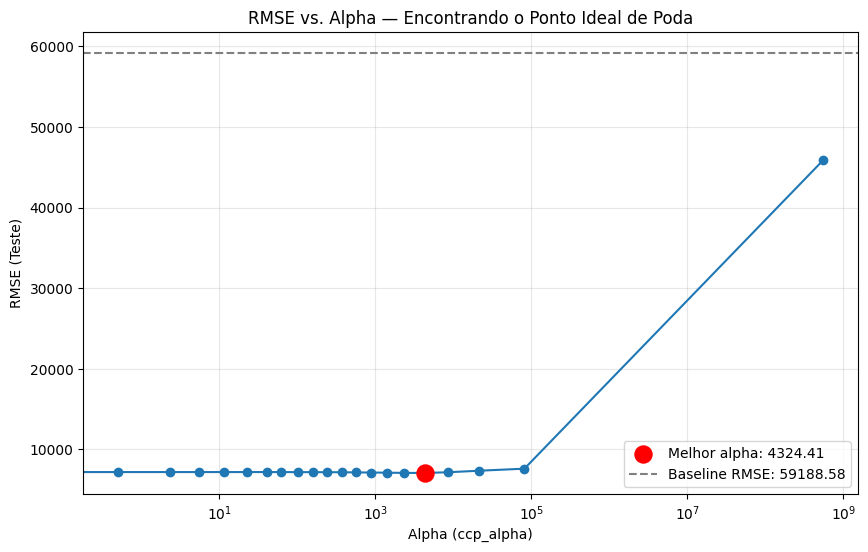


Melhor alpha encontrado: 4324.41
RMSE nesse ponto: 7048.46
Comparação com baseline (média): 59188.58


In [18]:
#funcao gerada por ia para descobrir o ponto ideal atraves de um grafico

import matplotlib.pyplot as plt
import pandas as pd

# Transforma os resultados em um DataFrame para facilitar a manipulação
df_resultados = pd.DataFrame(resultados_poda)

# Encontra o alpha que gerou o menor RMSE
melhor_linha = df_resultados.loc[df_resultados['rmse'].idxmin()]
melhor_alpha = melhor_linha['alpha']
melhor_rmse = melhor_linha['rmse']

# Plot

plt.figure(figsize=(10, 6))
plt.plot(df_resultados['alpha'], df_resultados['rmse'], marker='o', linestyle='-')
plt.xscale('log')

# Marca o ponto ideal
plt.scatter(melhor_alpha, melhor_rmse, color='red', s=150, zorder=5, label=f'Melhor alpha: {melhor_alpha:.2f}')

# Linha de referência do baseline
plt.axhline(y=rmse, color='gray', linestyle='--', label=f'Baseline RMSE: {rmse:.2f}')

plt.xlabel('Alpha (ccp_alpha)')
plt.ylabel('RMSE (Teste)')
plt.title('RMSE vs. Alpha — Encontrando o Ponto Ideal de Poda')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nMelhor alpha encontrado: {melhor_alpha:.2f}")
print(f"RMSE nesse ponto: {melhor_rmse:.2f}")
print(f"Comparação com baseline (média): {rmse:.2f}")

In [19]:
modelo_final = DecisionTreeRegressor(random_state=42, ccp_alpha=melhor_alpha)
modelo_final.fit(X_train_final, y_train)

profundidade = modelo_final.get_depth()
folhas = modelo_final.get_n_leaves()

print(f"Profundidade final: {profundidade}")
print(f"Número de folhas finais: {folhas}")

Profundidade final: 48
Número de folhas finais: 940


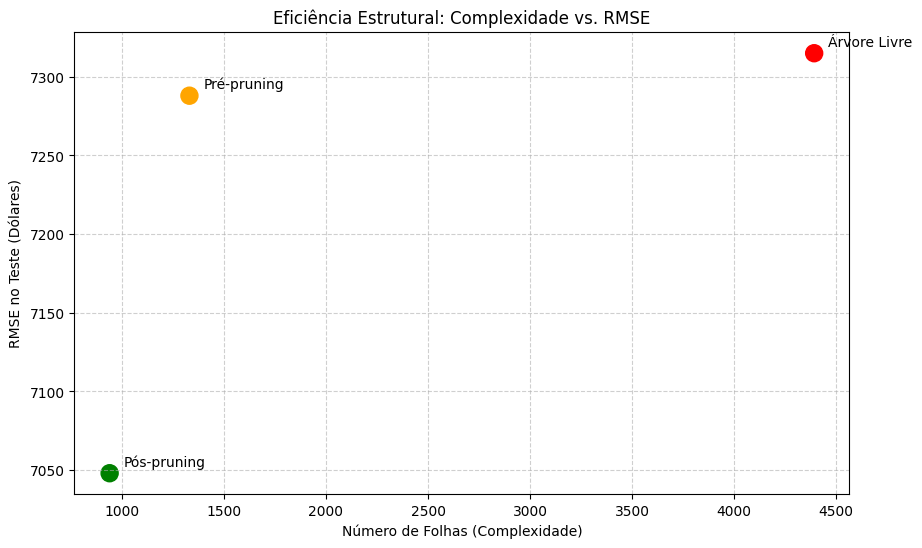

In [20]:
import matplotlib.pyplot as plt

folhas = [4392, 1331, 940]
erros = [7315, 7288, 7048]
nomes = ['Árvore Livre', 'Pré-pruning', 'Pós-pruning']
cores = ['red', 'orange', 'green']

plt.figure(figsize=(10, 6))

plt.scatter(folhas, erros, color=cores, s=150)

# Adicionando as legendas ao lado de cada ponto
for i, txt in enumerate(nomes):
    plt.annotate(txt, (folhas[i], erros[i]), xytext=(10, 5), textcoords='offset points')

plt.title('Eficiência Estrutural: Complexidade vs. RMSE')
plt.xlabel('Número de Folhas (Complexidade)')
plt.ylabel('RMSE no Teste (Dólares)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [21]:
plt.savefig('image_e1b04d.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

In [22]:
plt.savefig('image_e1b04a.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

In [23]:
#Teste d R ao quadrado para melhor

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def avaliar_modelo(modelo, X_treino, y_treino, X_teste, y_teste, nome):
    pred_treino = modelo.predict(X_treino)
    pred_teste = modelo.predict(X_teste)

    rmse_treino = mean_squared_error(y_treino, pred_treino) ** 0.5
    rmse_teste = mean_squared_error(y_teste, pred_teste) ** 0.5

    mae_treino = mean_absolute_error(y_treino, pred_treino)
    mae_teste = mean_absolute_error(y_teste, pred_teste)

    r2_treino = r2_score(y_treino, pred_treino)
    r2_teste = r2_score(y_teste, pred_teste)

    print(f"\n===== {nome} =====")
    print(f"RMSE Treino: US$ {rmse_treino:,.2f}")
    print(f"RMSE Teste:  US$ {rmse_teste:,.2f}")
    print(f"MAE Treino:  US$ {mae_treino:,.2f}")
    print(f"MAE Teste:   US$ {mae_teste:,.2f}")
    print(f"R² Treino:   {r2_treino:.4f}")
    print(f"R² Teste:    {r2_teste:.4f}")
    print(f"Gap R²:      {r2_treino - r2_teste:.4f}")

    return {
        "Modelo": nome,
        "RMSE Treino": rmse_treino,
        "RMSE Teste": rmse_teste,
        "MAE Treino": mae_treino,
        "MAE Teste": mae_teste,
        "R² Treino": r2_treino,
        "R² Teste": r2_teste,
        "Gap R²": r2_treino - r2_teste
    }



In [24]:

resultado_arvore = avaliar_modelo(
    modelo_arvore,
    X_train_final,
    y_train,
    X_test_final,
    y_test,
    "Árvore Livre"
)

resultado_pre = avaliar_modelo(
    modelo_arvore_podada,
    X_train_final,
    y_train,
    X_test_final,
    y_test,
    "Pré-pruning"
)

resultado_pos = avaliar_modelo(
    modelo_final,
    X_train_final,
    y_train,
    X_test_final,
    y_test,
    "Pós-pruning"
)



df_avaliacao = pd.DataFrame([
    resultado_arvore,
    resultado_pre,
    resultado_pos
])

df_avaliacao


===== Árvore Livre =====
RMSE Treino: US$ 5,062.42
RMSE Teste:  US$ 7,163.33
MAE Treino:  US$ 1,204.53
MAE Teste:   US$ 3,097.59
R² Treino:   0.9930
R² Teste:    0.9854
Gap R²:      0.0076

===== Pré-pruning =====
RMSE Treino: US$ 20,162.73
RMSE Teste:  US$ 21,174.73
MAE Treino:  US$ 8,559.34
MAE Teste:   US$ 8,684.02
R² Treino:   0.8889
R² Teste:    0.8720
Gap R²:      0.0169

===== Pós-pruning =====
RMSE Treino: US$ 5,257.81
RMSE Teste:  US$ 7,048.46
MAE Treino:  US$ 1,847.56
MAE Teste:   US$ 3,009.48
R² Treino:   0.9924
R² Teste:    0.9858
Gap R²:      0.0066


,Modelo,RMSE Treino,RMSE Teste,MAE Treino,MAE Teste,R² Treino,R² Teste,Gap R²
0,Árvore Livre,5062.415226,7163.327118,1204.527021,3097.586409,0.992997,0.985351,0.007647
1,Pré-pruning,20162.728951,21174.728663,8559.342306,8684.021840,0.888919,0.871996,0.016923
2,Pós-pruning,5257.810549,7048.463701,1847.557981,3009.478316,0.992446,0.985817,0.006630


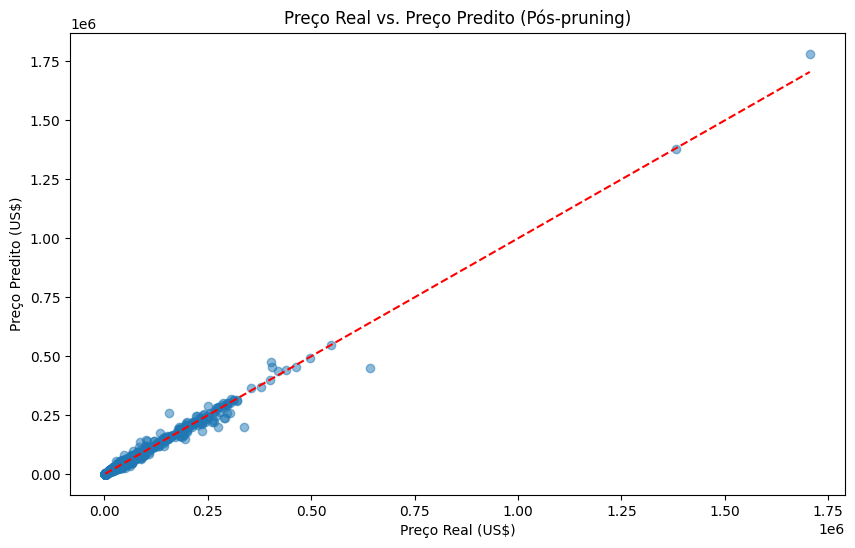

In [25]:
pred_pos = modelo_final.predict(X_test_final)

min_val = y_test.min()
max_val = y_test.max()

plt.figure(figsize=(10,6))
plt.scatter(y_test, pred_pos, alpha=0.5)
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
plt.xlabel("Preço Real (US$)")
plt.ylabel("Preço Predito (US$)")
plt.title("Preço Real vs. Preço Predito (Pós-pruning)")

plt.show()

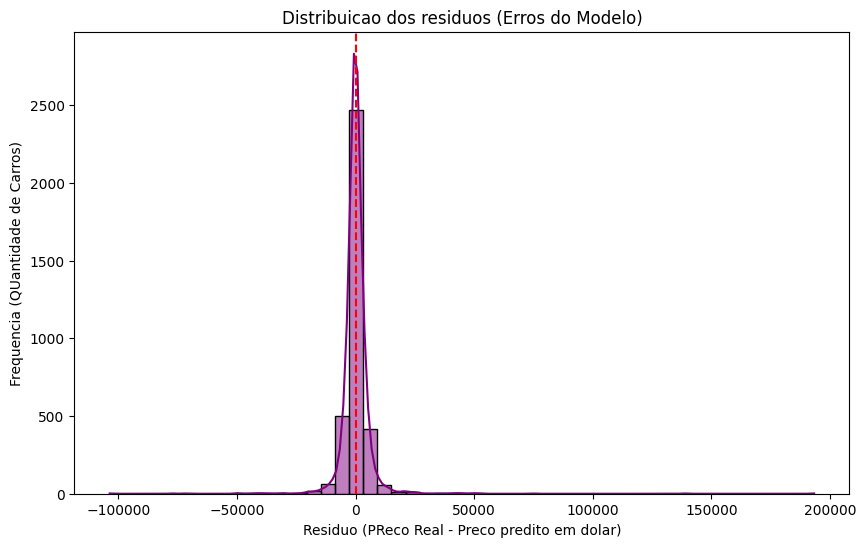

In [26]:
#Analise de residuos
residuo = y_test - pred_pos
plt.figure(figsize=(10, 6))
sns.histplot(residuo, bins=50, kde=True, color='purple')
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Distribuicao dos residuos (Erros do Modelo)")
plt.xlabel("Residuo (PReco Real - Preco predito em dolar)")
plt.ylabel("Frequencia (QUantidade de Carros)")

plt.show()

In [27]:
#investigacao dos maiores erros
import numpy as np

erro_absoluto = np.abs(y_test - pred_pos)
df_erros = pd.DataFrame({
    'Preco Real': y_test,
    'Preco Predito': pred_pos,
    'Erro Absoluto': erro_absoluto
})

top_5_erros = df_erros.sort_values(by='Erro Absoluto', ascending=False).head(5)
top_5_erros

,Preco Real,Preco Predito,Erro Absoluto
4024,643330,450000.0,193330.0
2858,337000,198100.0,138900.0
3522,156300,260000.0,103700.0
11364,1705769,1782951.0,77182.0
9689,275000,200500.0,74500.0


teste com bagging para outro laboratorio


In [31]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Relembrando a nossa Árvore Individual (Livre) para ter um Baseline justo
arvore_individual = DecisionTreeRegressor(random_state=42)
arvore_individual.fit(X_train_final, y_train)
pred_arvore = arvore_individual.predict(X_test_final)
rmse_arvore = mean_squared_error(y_test, pred_arvore) ** 0.5

# 2. Construindo o nosso primeiro Ensemble (Bagging)
# Por padrão, n_estimators=10 (ele criará 10 árvores diferentes via Bootstrap)
modelo_bagging_10 = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    n_estimators=10,
    random_state=42
)
modelo_bagging_10.fit(X_train_final, y_train)
pred_bagging = modelo_bagging_10.predict(X_test_final)
rmse_bagging = mean_squared_error(y_test, pred_bagging) ** 0.5

print(f"RMSE Árvore Individual: US$ {rmse_arvore:,.2f}")
print(f"RMSE Bagging (10 árvores): US$ {rmse_bagging:,.2f}")

RMSE Árvore Individual: US$ 7,163.33
RMSE Bagging (10 árvores): US$ 9,929.38
